In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"D:\Ultimate Programming\Data Bases\Project Dataset\price of a Football player.csv")

In [3]:
data.head(2)

,name,club,age,position,position_cat,market_value,page_views,fpl_value,fpl_sel,fpl_points,region,nationality,new_foreign,age_cat,club_id,big_club,new_signing
0,Alexis Sanchez,Arsenal,28,LW,1,65.0,4329,12.0,17.10%,264,3.0,Chile,0,4,1,1,0
1,Mesut Ozil,Arsenal,28,AM,1,50.0,4395,9.5,5.60%,167,2.0,Germany,0,4,1,1,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          461 non-null    object 
 1   club          461 non-null    object 
 2   age           461 non-null    int64  
 3   position      461 non-null    object 
 4   position_cat  461 non-null    int64  
 5   market_value  461 non-null    float64
 6   page_views    461 non-null    int64  
 7   fpl_value     461 non-null    float64
 8   fpl_sel       461 non-null    object 
 9   fpl_points    461 non-null    int64  
 10  region        460 non-null    float64
 11  nationality   461 non-null    object 
 12  new_foreign   461 non-null    int64  
 13  age_cat       461 non-null    int64  
 14  club_id       461 non-null    int64  
 15  big_club      461 non-null    int64  
 16  new_signing   461 non-null    int64  
dtypes: float64(3), int64(9), object(5)
memory usage: 61.4+ KB


In [5]:
df = data.drop('name', axis=1)

In [6]:
df['fpl_sel'] = df['fpl_sel'].str.rstrip('%').astype(float)

In [7]:
df.new_signing.value_counts()

new_signing
0    394
1     67
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,position_cat,market_value,page_views,fpl_value,fpl_sel,fpl_points,region,new_foreign,age_cat,club_id,big_club,new_signing
count,461.000000,461.000000,461.000000,461.000000,461.000000,461.000000,461.000000,460.000000,461.000000,461.000000,461.000000,461.000000,461.000000
mean,26.804772,2.180043,11.012039,763.776573,5.447939,3.244252,57.314534,1.993478,0.034707,3.206074,10.334056,0.303688,0.145336
std,3.961892,1.000061,12.257403,931.805757,1.346695,5.675657,53.113811,0.957689,0.183236,1.279795,5.726475,0.460349,0.352822
min,17.000000,1.000000,0.050000,3.000000,4.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,24.000000,1.000000,3.000000,220.000000,4.500000,0.200000,5.000000,1.000000,0.000000,2.000000,6.000000,0.000000,0.000000
50%,27.000000,2.000000,7.000000,460.000000,5.000000,1.000000,51.000000,2.000000,0.000000,3.000000,10.000000,0.000000,0.000000
75%,30.000000,3.000000,15.000000,896.000000,5.500000,3.300000,94.000000,2.000000,0.000000,4.000000,15.000000,1.000000,0.000000
max,38.000000,4.000000,75.000000,7664.000000,12.500000,45.000000,264.000000,4.000000,1.000000,6.000000,20.000000,1.000000,1.000000


In [10]:
q1 = df['page_views'].quantile(0.25)
q3 = df['page_views'].quantile(0.75)

iqr = q3 - q1
min_range = q1 - (iqr*1.5)
max_range = q3 + (iqr*1.5)

In [11]:
df = df[df['page_views'] <= max_range]

In [12]:
df.describe()

,age,position_cat,market_value,page_views,fpl_value,fpl_sel,fpl_points,region,new_foreign,age_cat,club_id,big_club,new_signing
count,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,422.000000,423.000000,423.000000,423.000000,423.000000,423.000000
mean,26.829787,2.255319,8.874823,541.775414,5.193853,2.519149,50.430260,1.981043,0.037825,3.208038,10.458629,0.252955,0.139480
std,3.974368,0.988591,8.651712,435.370011,0.941543,4.108382,46.770482,0.954858,0.190999,1.278414,5.794062,0.435220,0.346857
min,17.000000,1.000000,0.050000,3.000000,4.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,24.000000,1.000000,2.500000,209.000000,4.500000,0.200000,2.000000,1.000000,0.000000,2.000000,6.000000,0.000000,0.000000
50%,27.000000,2.000000,6.000000,422.000000,5.000000,0.800000,44.000000,2.000000,0.000000,3.000000,10.000000,0.000000,0.000000
75%,30.000000,3.000000,12.000000,722.000000,5.500000,2.500000,87.500000,2.000000,0.000000,4.000000,16.000000,1.000000,0.000000
max,38.000000,4.000000,40.000000,1877.000000,10.500000,26.500000,218.000000,4.000000,1.000000,6.000000,20.000000,1.000000,1.000000


In [13]:
df.shape

(423, 16)

## Exploratory Data Analysis

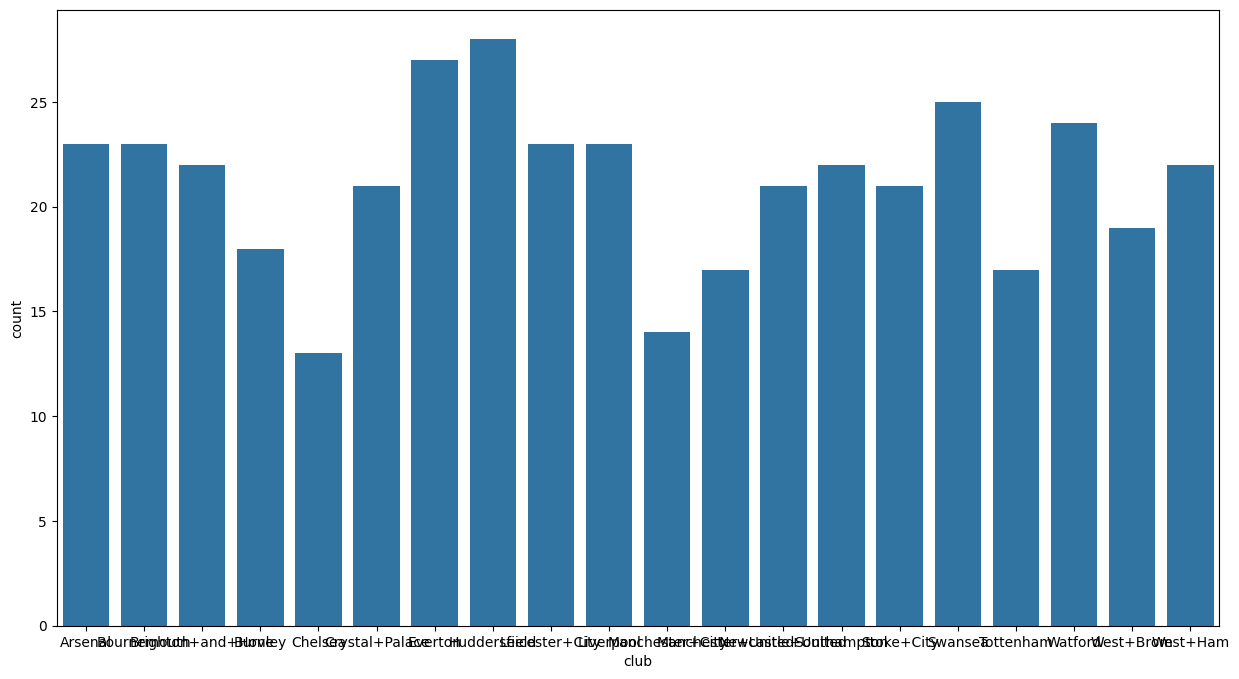

In [14]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, x='club')
plt.show()

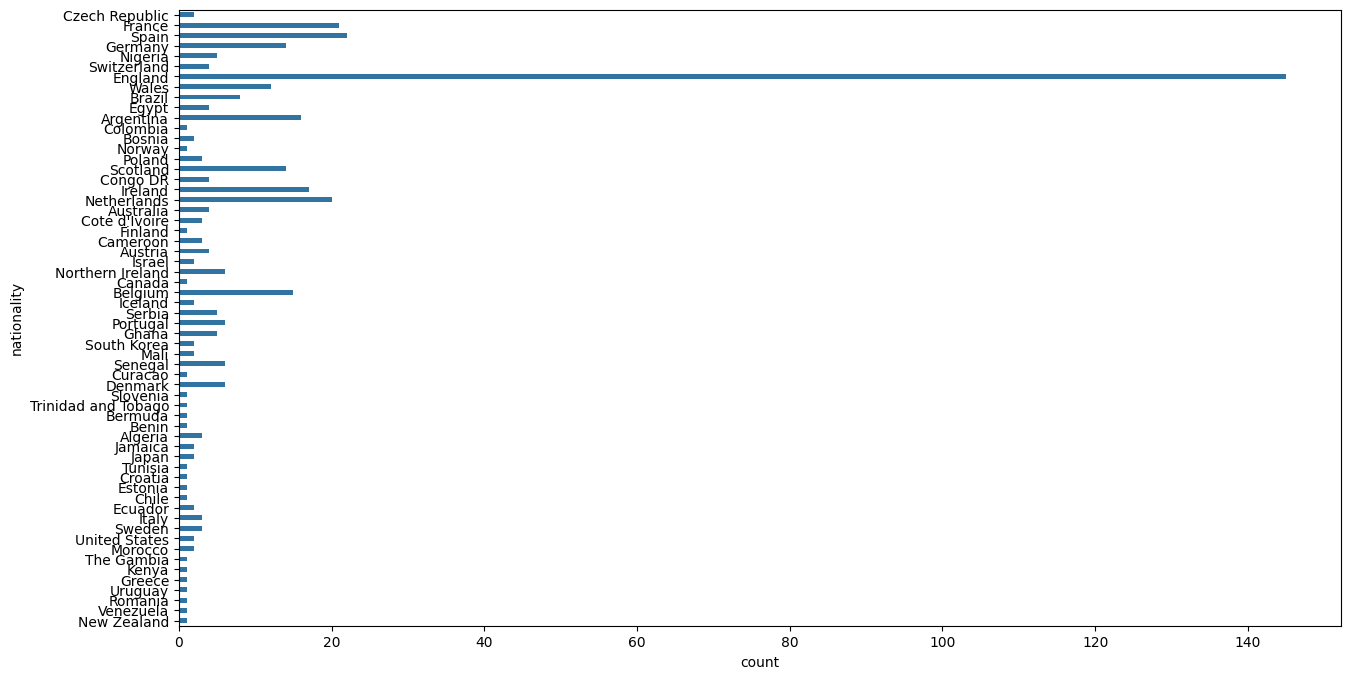

In [15]:
plt.figure(figsize=(15,8))
sns.countplot(data=df, y='nationality', gap=0.4)
plt.show()

# Data Preprocessing

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 423 entries, 2 to 460
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   club          423 non-null    object 
 1   age           423 non-null    int64  
 2   position      423 non-null    object 
 3   position_cat  423 non-null    int64  
 4   market_value  423 non-null    float64
 5   page_views    423 non-null    int64  
 6   fpl_value     423 non-null    float64
 7   fpl_sel       423 non-null    float64
 8   fpl_points    423 non-null    int64  
 9   region        422 non-null    float64
 10  nationality   423 non-null    object 
 11  new_foreign   423 non-null    int64  
 12  age_cat       423 non-null    int64  
 13  club_id       423 non-null    int64  
 14  big_club      423 non-null    int64  
 15  new_signing   423 non-null    int64  
dtypes: float64(4), int64(9), object(3)
memory usage: 56.2+ KB


In [18]:
x = df.drop('fpl_points', axis=1)
y = df['fpl_points']

In [19]:
num_cols = ["age", "market_value", "page_views", "fpl_value", "fpl_sel"]
cat_cols = ["club", "position", "region", "nationality"]

ct = ColumnTransformer(
    transformers=[
        ('no', MinMaxScaler(), num_cols),
        ('ca', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ], remainder='passthrough')

In [20]:
ct.fit(x)

,transformers,"[('no', ...), ('ca', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [21]:
x_en = ct.transform(x) 
x_en = pd.DataFrame(x_en, columns=ct.get_feature_names_out())

In [22]:
x_en.head(4)

,no__age,no__market_value,no__page_views,no__fpl_value,no__fpl_sel,ca__club_Bournemouth,ca__club_Brighton+and+Hove,ca__club_Burnley,ca__club_Chelsea,ca__club_Crystal+Palace,...,ca__nationality_United States,ca__nationality_Uruguay,ca__nationality_Venezuela,ca__nationality_Wales,remainder__position_cat,remainder__new_foreign,remainder__age_cat,remainder__club_id,remainder__big_club,remainder__new_signing
0,0.857143,0.173967,0.814301,0.230769,0.222642,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,6.0,1.0,1.0,0.0
1,0.666667,0.549437,0.485059,0.307692,0.026415,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,4.0,1.0,1.0,0.0
2,0.238095,0.749687,0.892209,0.307692,0.516981,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,2.0,1.0,1.0,0.0
3,0.666667,0.324155,0.294557,0.230769,0.177358,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,4.0,1.0,1.0,0.0


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x_en, y, test_size=0.2, random_state=42)

## Models 

In [24]:
from sklearn.linear_model import LinearRegression, LarsCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "LarsCV": LarsCV(),
    "RidgeCV": RidgeCV(),
    "Decision Tree": DecisionTreeRegressor(),
    "SVR": SVR()
}

In [26]:
for name, model in models.items():
    model.fit(x_train, y_train)
    acc_tr = round(model.score(x_train, y_train)*100, 2)
    acc_te = round(model.score(x_test, y_test)*100, 2)
    sc = round(r2_score(y_test, model.predict(x_test))*100,2)
    print(f"{name} => Training: {acc_tr} Testing: {acc_te} => r2_score: {sc}")

Linear Regression => Training: 80.32 Testing: 17.35 => r2_score: 17.35
LarsCV => Training: 76.11 Testing: 32.11 => r2_score: 32.11
RidgeCV => Training: 78.13 Testing: 37.34 => r2_score: 37.34
Decision Tree => Training: 100.0 Testing: 10.09 => r2_score: 10.09
SVR => Training: -0.32 Testing: -0.3 => r2_score: -0.3


# Method 2: 

In [27]:
from category_encoders import TargetEncoder

te = TargetEncoder()
df['club'] = te.fit_transform(df['club'], df['fpl_points'])
df['position'] = te.fit_transform(df['position'], df['fpl_points'])
df['region'] = te.fit_transform(df['region'], df['fpl_points'])
df['nationality'] = te.fit_transform(df['nationality'], df['fpl_points'])

In [28]:
df.head(2)

,club,age,position,position_cat,market_value,page_views,fpl_value,fpl_sel,fpl_points,region,nationality,new_foreign,age_cat,club_id,big_club,new_signing
2,52.455895,35,54.001681,4,7.0,1529,5.5,5.9,134,2.0,52.780695,0,6,1,1,0
4,52.455895,31,48.871637,3,22.0,912,6.0,0.7,121,2.0,44.454610,0,4,1,1,0


In [29]:
scaler = MinMaxScaler()

df2 = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [30]:
df2.head(3)

,club,age,position,position_cat,market_value,page_views,fpl_value,fpl_sel,fpl_points,region,nationality,new_foreign,age_cat,club_id,big_club,new_signing
0,0.808337,0.857143,0.492373,1.000000,0.173967,0.814301,0.230769,0.222642,0.614679,0.333333,0.440334,0.0,1.0,0.0,1.0,0.0
1,0.808337,0.666667,0.224721,0.666667,0.549437,0.485059,0.307692,0.026415,0.555046,0.333333,0.113271,0.0,0.6,0.0,1.0,0.0
2,0.808337,0.238095,0.750873,0.666667,0.749687,0.892209,0.307692,0.516981,0.545872,0.333333,0.596912,0.0,0.2,0.0,1.0,0.0


In [31]:
X = df2.drop('fpl_points', axis=1)
y = df2['fpl_points']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
for name, model in models.items():
    model.fit(x_train, y_train)
    acc_tr = round(model.score(x_train, y_train)*100, 2)
    acc_te = round(model.score(x_test, y_test)*100, 2)
    sc = round(r2_score(y_test, model.predict(x_test))*100,2)
    print(f"{name} => Training: {acc_tr} Testing: {acc_te} => r2_score: {sc}")

Linear Regression => Training: 80.32 Testing: 17.35 => r2_score: 17.35
LarsCV => Training: 76.11 Testing: 32.11 => r2_score: 32.11
RidgeCV => Training: 78.13 Testing: 37.34 => r2_score: 37.34
Decision Tree => Training: 100.0 Testing: 1.88 => r2_score: 1.88
SVR => Training: 57.85 Testing: 30.63 => r2_score: 30.63


In [34]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=500)
model.fit(x_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
model.score(x_train, y_train)*100, model.score(x_test, y_test)*100

(95.08430708574865, 41.33832956694338)

In [40]:
from xgboost import XGBRegressor
model2 = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)
model2.fit(x_train, y_train)
model2.score(x_train, y_train)*100, model2.score(x_test, y_test)*100

(99.32704213321516, 45.575428087278965)